In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data=pd.read_csv("nepal_loadshedding_2012_2023.csv")
data

,year,month,month_name,season,group,district,population,num_businesses,daily_hours,weekly_hours,monthly_hours,household_loss_npr,business_loss_npr,total_household_loss_npr,total_business_loss_npr,year_month
0,2012,1,January,Winter,Group 1,Kathmandu,1500000,45000,15.06,105.4,451.8,24849.0,171684.0,9.318375e+09,7.725780e+09,2012-01
1,2012,1,January,Winter,Group 1,Lalitpur,300000,12000,15.75,110.2,472.5,23625.0,132300.0,1.771875e+09,1.587600e+09,2012-01
2,2012,1,January,Winter,Group 1,Bhaktapur,85000,8000,17.01,119.1,510.3,22964.0,112266.0,4.879850e+08,8.981280e+08,2012-01
3,2012,1,January,Winter,Group 1,Pokhara,450000,15000,18.00,126.0,540.0,27000.0,162000.0,3.037500e+09,2.430000e+09,2012-01
4,2012,1,January,Winter,Group 1,Chitwan,580000,18000,18.00,126.0,540.0,22680.0,135000.0,3.288600e+09,2.430000e+09,2012-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10075,2023,12,December,Winter,Group 7,Biratnagar,240000,11000,2.00,14.0,60.0,2880.0,16200.0,1.728000e+08,1.782000e+08,2023-12
10076,2023,12,December,Winter,Group 7,Birgunj,190000,9500,1.89,13.2,56.7,2608.0,14742.0,1.238800e+08,1.400490e+08,2023-12
10077,2023,12,December,Winter,Group 7,Butwal,135000,7000,1.74,12.2,52.2,2088.0,10962.0,7.047000e+07,7.673400e+07,2023-12
10078,2023,12,December,Winter,Group 7,Dharan,130000,6500,2.28,16.0,68.4,3010.0,16416.0,9.782500e+07,1.067040e+08,2023-12


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      10080 non-null  int64  
 1   month                     10080 non-null  int64  
 2   month_name                10080 non-null  object 
 3   season                    10080 non-null  object 
 4   group                     10080 non-null  object 
 5   district                  10080 non-null  object 
 6   population                10080 non-null  int64  
 7   num_businesses            10080 non-null  int64  
 8   daily_hours               10080 non-null  float64
 9   weekly_hours              10080 non-null  float64
 10  monthly_hours             10080 non-null  float64
 11  household_loss_npr        10080 non-null  float64
 12  business_loss_npr         10080 non-null  float64
 13  total_household_loss_npr  10080 non-null  float64
 14  total_

In [4]:
len(data.isna())

10080

In [5]:
district=data["district"].unique()

In [6]:
grp=data["group"].unique()

In [118]:
year=data["year"].unique()


In [8]:
seasons=data["season"].unique()

In [9]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

In [10]:
data["month_name"]=pd.Categorical(data["month_name"],categories=month_order,ordered=True)

In [11]:
data

,year,month,month_name,season,group,district,population,num_businesses,daily_hours,weekly_hours,monthly_hours,household_loss_npr,business_loss_npr,total_household_loss_npr,total_business_loss_npr,year_month
0,2012,1,January,Winter,Group 1,Kathmandu,1500000,45000,15.06,105.4,451.8,24849.0,171684.0,9.318375e+09,7.725780e+09,2012-01
1,2012,1,January,Winter,Group 1,Lalitpur,300000,12000,15.75,110.2,472.5,23625.0,132300.0,1.771875e+09,1.587600e+09,2012-01
2,2012,1,January,Winter,Group 1,Bhaktapur,85000,8000,17.01,119.1,510.3,22964.0,112266.0,4.879850e+08,8.981280e+08,2012-01
3,2012,1,January,Winter,Group 1,Pokhara,450000,15000,18.00,126.0,540.0,27000.0,162000.0,3.037500e+09,2.430000e+09,2012-01
4,2012,1,January,Winter,Group 1,Chitwan,580000,18000,18.00,126.0,540.0,22680.0,135000.0,3.288600e+09,2.430000e+09,2012-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10075,2023,12,December,Winter,Group 7,Biratnagar,240000,11000,2.00,14.0,60.0,2880.0,16200.0,1.728000e+08,1.782000e+08,2023-12
10076,2023,12,December,Winter,Group 7,Birgunj,190000,9500,1.89,13.2,56.7,2608.0,14742.0,1.238800e+08,1.400490e+08,2023-12
10077,2023,12,December,Winter,Group 7,Butwal,135000,7000,1.74,12.2,52.2,2088.0,10962.0,7.047000e+07,7.673400e+07,2023-12
10078,2023,12,December,Winter,Group 7,Dharan,130000,6500,2.28,16.0,68.4,3010.0,16416.0,9.782500e+07,1.067040e+08,2023-12


In [56]:
yearly_datasets={}
df_={}
for yr in year:
    yearly_datasets[yr]=data[data["year"]==yr].copy()
    df_[yr]=yearly_datasets[yr].groupby("month_name",observed=False)["monthly_hours"].mean()
    

In [64]:
print(f"The maximum loadshedding was during the month {df_[2015].argmax()}")

The maximum loadshedding was during the month 1


In [72]:
data2015=pd.DataFrame(df_[2015])
data2015

,monthly_hours
month_name,
January,507.780000
February,508.517143
March,439.731429
April,437.678571
May,361.315714
June,184.032857
July,184.255714
August,183.484286
September,320.592857


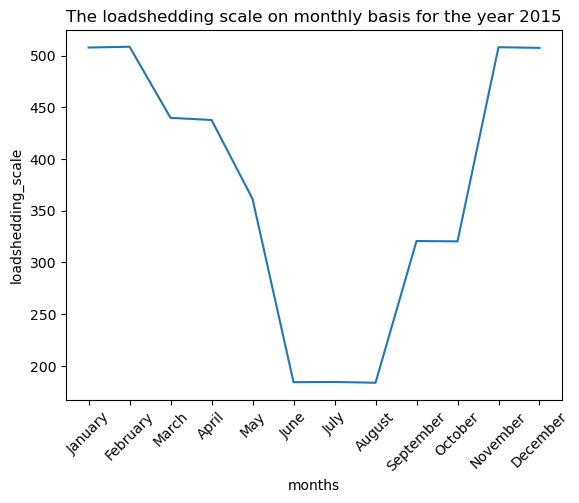

In [88]:
plt.plot(data2015)
plt.title("The loadshedding scale on monthly basis for the year 2015")
plt.xlabel("months")
plt.ylabel("loadshedding_scale")
plt.xticks(rotation=45)
plt.show()


In [129]:
area={}
for m in district:
    m_data=data[data["district"]=="Kathmandu"].copy()
    area[m]=m_data.groupby(["year","month_name"],observed=False)["monthly_hours"].mean().reset_index()

In [213]:
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}
ktm_df["num_month"] = ktm_df["month_name"].map(month_map)

In [219]:
ktm_df=area["Kathmandu"]
ktm_df1=ktm_df.drop(["month_name"],axis=1)
ktm_df1

,year,monthly_hours,num_month
0,2012,493.414286,1
1,2012,484.328571,2
2,2012,400.200000,3
3,2012,402.814286,4
4,2012,327.128571,5
...,...,...,...
139,2023,13.500000,8
140,2023,19.328571,9
141,2023,23.700000,10
142,2023,24.557143,11


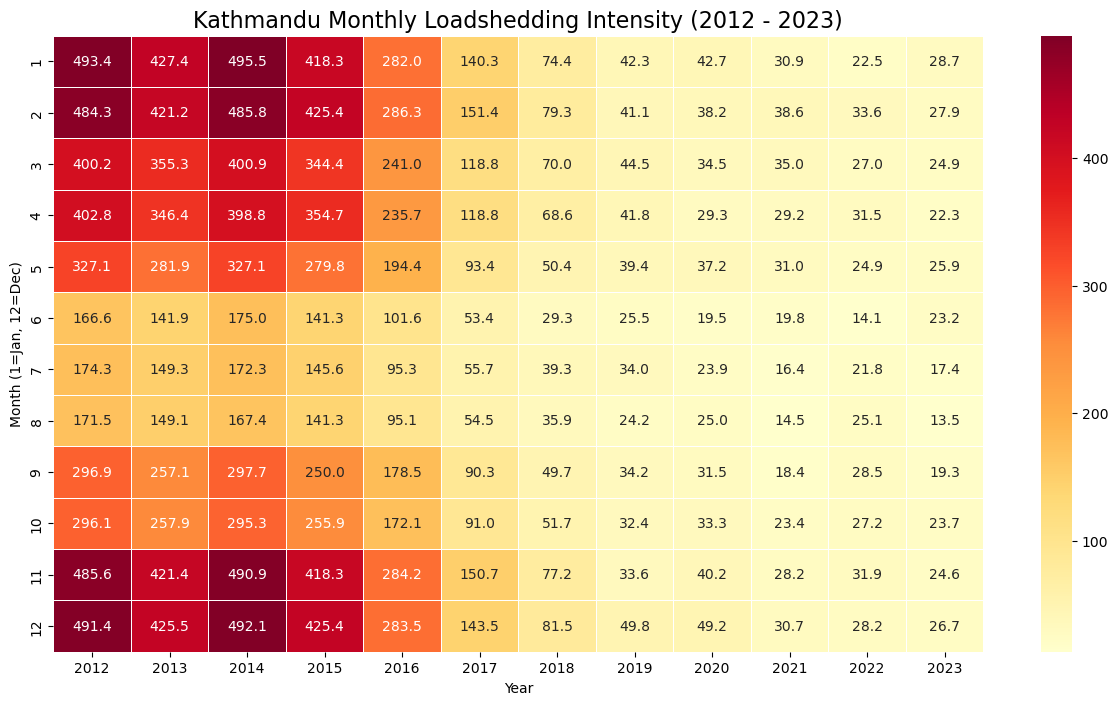

In [227]:
heatmap_matrix = ktm_df.pivot(index='num_month', columns='year', values='monthly_hours')

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5)

plt.title("Kathmandu Monthly Loadshedding Intensity (2012 - 2023)", fontsize=16)
plt.ylabel("Month (1=Jan, 12=Dec)")
plt.xlabel("Year")
plt.savefig("Kathmandu_monthly_loadshedding.png")
plt.show()

In [143]:
ktm_yearly=ktm_df.groupby("year")["monthly_hours"].mean().reset_index()
ktm_yearly

,year,monthly_hours
0,2012,349.192857
1,2013,302.867857
2,2014,349.917857
3,2015,300.028571
4,2016,204.135714
5,2017,105.160714
6,2018,58.928571
7,2019,36.900000
8,2020,33.717857
9,2021,26.342857


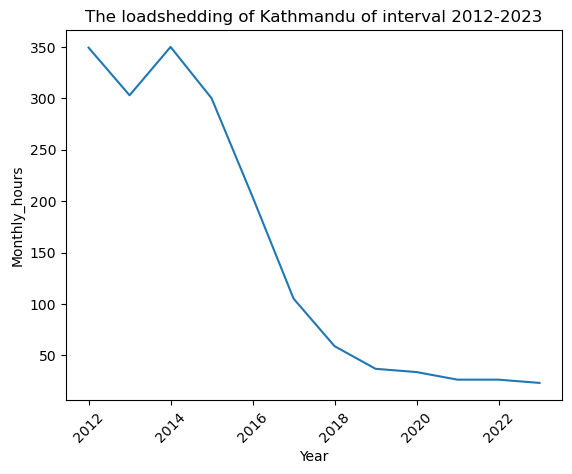

In [229]:

plt.plot(ktm_yearly["year"],ktm_yearly["monthly_hours"])
plt.xlabel("Year")
plt.ylabel("Monthly_hours")
plt.xticks(rotation=45)
plt.title("The loadshedding of Kathmandu of interval 2012-2023")
plt.savefig("kathmandu_loadshedding.png")
plt.show()

In [157]:
seasons_df=data.groupby("season")["monthly_hours"].mean().reset_index()
seasons_df

,season,monthly_hours
0,Autumn,160.939107
1,Monsoon,95.525238
2,Spring,214.750714
3,Summer,179.502143
4,Winter,243.151518


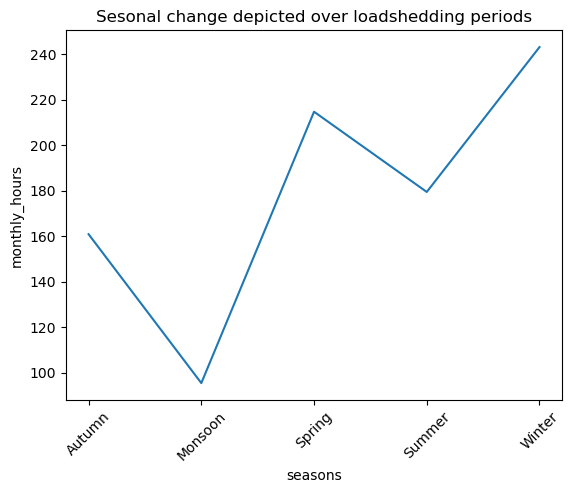

In [231]:
plt.plot(seasons_df["season"],seasons_df["monthly_hours"])
plt.title("Sesonal change depicted over loadshedding periods")
plt.xlabel("seasons")
plt.ylabel("monthly_hours")
plt.xticks(rotation=45)
plt.savefig("season_change_loadshedding.png")
plt.show()

In [191]:
yearlyh_loss=data.groupby("year")["total_household_loss_npr"].mean().reset_index()
yearlyb_loss=data.groupby("year")["total_business_loss_npr"].mean().reset_index()

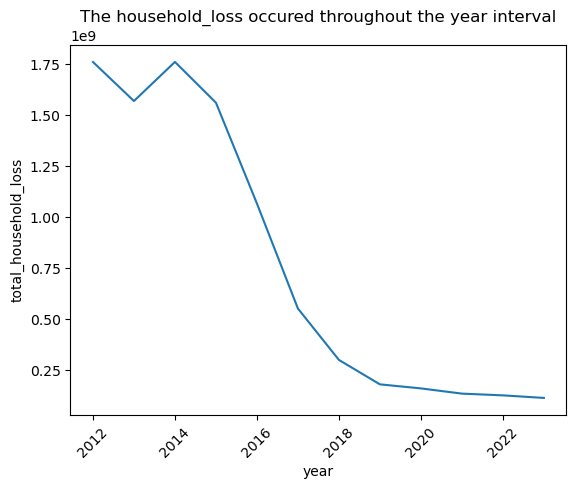

In [233]:
plt.plot(yearlyh_loss["year"],yearlyh_loss["total_household_loss_npr"])
plt.ylabel("total_household_loss")
plt.xlabel("year")
plt.xticks(rotation=45)
plt.title("The household_loss occured throughout the year interval")
plt.savefig("household_loss_loadshedding.png")
plt.show()

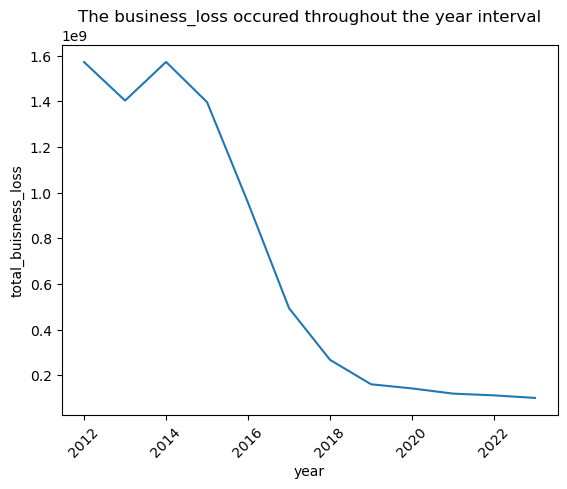

In [235]:
plt.plot(yearlyb_loss["year"],yearlyb_loss["total_business_loss_npr"])
plt.ylabel("total_buisness_loss")
plt.xlabel("year")
plt.xticks(rotation=45)
plt.title("The business_loss occured throughout the year interval")
plt.savefig("Buisness_loss_loadshedding.png")
plt.show()